In [47]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, hamming_loss,confusion_matrix
from sklearn.decomposition import PCA

In [48]:
## Data is stored in the cache for ease of access / disposal
yt_path= kagglehub.dataset_download("bsthere/youtube-trending-videos-stats-2026")

print("Path to YouTube dataset files:", yt_path)

Path to YouTube dataset files: C:\Users\sheic\.cache\kagglehub\datasets\bsthere\youtube-trending-videos-stats-2026\versions\3


In [49]:
## Import US YouTube Data
yt_df = pd.read_csv(yt_path + "/US_trending.csv")
yt_ca_df = pd.read_csv(yt_path + "/CA_trending.csv")

yt_df = pd.concat([yt_df, yt_ca_df], ignore_index=True)
print(yt_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 32600 entries, 0 to 32599
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   video_id       32600 non-null  str  
 1   trending_date  32600 non-null  str  
 2   title          32600 non-null  str  
 3   channel_title  32598 non-null  str  
 4   views          32600 non-null  int64
 5   likes          32600 non-null  int64
 6   dislikes       32600 non-null  int64
 7   publish_time   32600 non-null  str  
 8   category_id    32600 non-null  int64
 9   tags           32600 non-null  str  
 10  comments       32600 non-null  int64
 11  channel_id     32600 non-null  str  
 12  description    27433 non-null  str  
dtypes: int64(5), str(8)
memory usage: 3.2 MB
None


In [50]:
## Identifying maximum values
print("Maximum Likes: ")
print(yt_df.iloc[yt_df['likes'].idxmax()])

print("\n Maximum Dislikes: ")
print(yt_df.iloc[yt_df['dislikes'].idxmax()])

print("\n Maximum Comments: ")
print(yt_df.iloc[yt_df['comments'].idxmax()])

print("\n Maximum Views: ")
print(yt_df.iloc[yt_df['views'].idxmax()])

## Note maximum dislikes is 0, likely because YouTube hides dislikes these days.


Maximum Likes: 
video_id                                               HyHNuVaZJ-k
trending_date                                             26.26.02
title                   Gorillaz - Feel Good Inc. (Official Video)
channel_title                                             Gorillaz
views                                                   1105363145
likes                                                      8968049
dislikes                                                         0
publish_time                                  2016-06-28T12:53:12Z
category_id                                                     10
tags             gorillaz|Feel Good Inc.|Feel Good Inc|feel|goo...
comments                                                    232242
channel_id                                UCfIXdjDQH9Fau7y99_Orpjw
description      Official HD Video for Gorillaz' fantastic trac...
Name: 29226, dtype: object

 Maximum Dislikes: 
video_id                                               5Q_sCOFwC5

In [51]:
## Identifying minimum values
print("Minimum Likes: ")
print(yt_df.iloc[yt_df['likes'].idxmin()])

print("\nMinimum Dislikes: ")
print(yt_df.iloc[yt_df['dislikes'].idxmin()])

print("\nMinimum Comments: ")
print(yt_df.iloc[yt_df['comments'].idxmin()])

print("\nMinimum Views: ")
print(yt_df.iloc[yt_df['views'].idxmin()])

## Note outlier values: videos posted at the time the data was pulled

Minimum Likes: 
video_id                                               mlH_7dkZMrc
trending_date                                             26.26.02
title               The State of the Union and Democratic Response
channel_title                                                  CNN
views                                                            0
likes                                                            0
dislikes                                                         0
publish_time                                  2026-02-25T13:50:58Z
category_id                                                     24
tags                                                        [none]
comments                                                         0
channel_id                                UCStfhR2V58QkCCyq_8dlk6g
description      President Donald Trump delivers the State of t...
Name: 14, dtype: object

Minimum Dislikes: 
video_id                                               5Q_sCOFwC5g
tr

In [52]:
# Likes Qualities
print("*** Likes ***")
print("Max: ", yt_df['likes'].max())
print("Mean: ", np.mean(yt_df['likes']))
print("Median: ", np.median(yt_df['likes']))
print("Variance: ", np.var(yt_df['likes']))
print("Standard distribution: ", np.std(yt_df['likes']))


*** Likes ***
Max:  8968049
Mean:  45724.53512269939
Median:  7213.0
Variance:  25675638022.63428
Standard distribution:  160236.19448375038


28645.5 1028.75 27616.75
69984


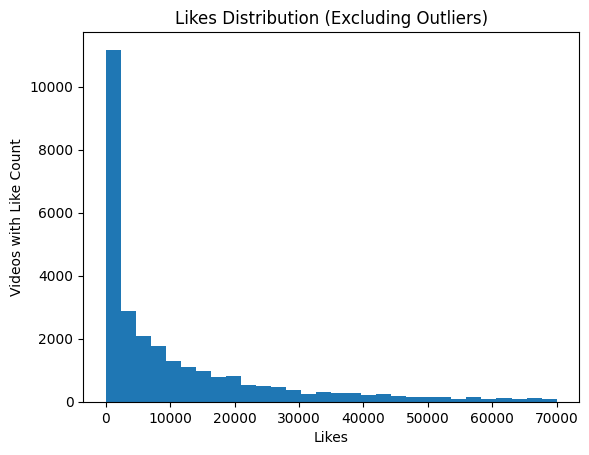

In [53]:
# Likes distribution (excluding outliers)
q75, q25 = np.percentile(yt_df['likes'], [75, 25])
iqr = q75 - q25

print(q75, q25, iqr)
no_outliers = yt_df[yt_df['likes'] < (q75 + iqr*1.5)]
no_outliers = no_outliers[no_outliers['likes'] > (q25 - iqr*1.5)]

print(no_outliers['likes'].max())

plt.hist(no_outliers['likes'], bins=30)
plt.title("Likes Distribution (Excluding Outliers)")
plt.ylabel("Videos with Like Count")
plt.xlabel("Likes")
plt.show()

In [54]:
# Comments Qualities
print("*** Comments ***")
print("Max: ", yt_df['comments'].max())
print("Mean: ", np.mean(yt_df['comments']))
print("Median: ", np.median(yt_df['comments']))
print("Variance: ", np.var(yt_df['comments']))
print("Standard distribution: ", np.std(yt_df['comments']))

*** Comments ***
Max:  451909
Mean:  1561.009601226994
Median:  296.0
Variance:  50441828.52865014
Standard distribution:  7102.241091982878


1090.25 40.0 1050.25
2665


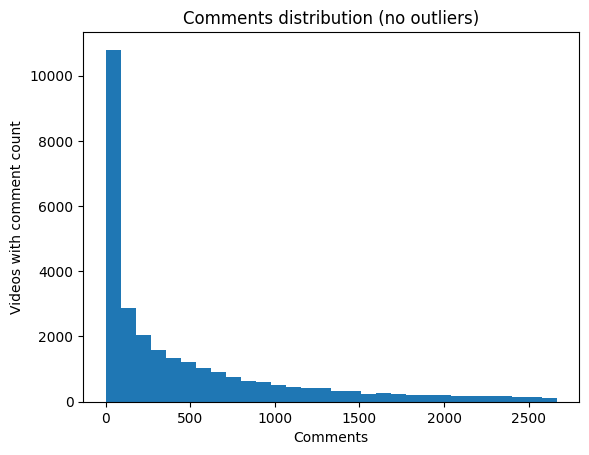

In [55]:
# Likes distribution (excluding outliers)
q75, q25 = np.percentile(yt_df['comments'], [75, 25])
iqr = q75 - q25

print(q75, q25, iqr)
no_outliers = yt_df[yt_df['comments'] < (q75 + iqr*1.5)]
no_outliers = no_outliers[no_outliers['comments'] > (q25 - iqr*1.5)]

print(no_outliers['comments'].max())

plt.hist(no_outliers['comments'], bins=30)
plt.title("Comments distribution (no outliers)")
plt.ylabel("Videos with comment count")
plt.xlabel("Comments")
plt.show()

In [56]:
# Comments Qualities
print("*** Views ***")
print("Max: ", yt_df['views'].max())
print("Mean: ", np.mean(yt_df['views']))
print("Median: ", np.median(yt_df['views']))
print("Variance: ", np.var(yt_df['views']))
print("Standard distribution: ", np.std(yt_df['views']))

*** Views ***
Max:  1105363145
Mean:  1938782.9591104295
Median:  260573.5
Variance:  238377126911942.28
Standard distribution:  15439466.535860049


1045241.25 47960.5 997280.75
2539568


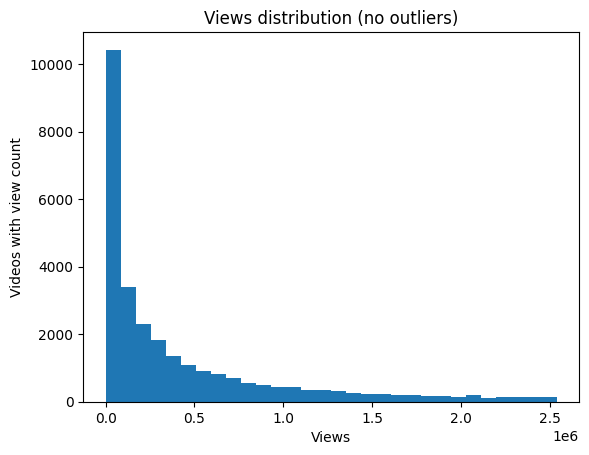

In [57]:
# Views distribution (excluding outliers)
q75, q25 = np.percentile(yt_df['views'], [75, 25])
iqr = q75 - q25

print(q75, q25, iqr)
no_outliers = yt_df[yt_df['views'] < (q75 + iqr*1.5)]
no_outliers = no_outliers[no_outliers['views'] > (q25 - iqr*1.5)]

print(no_outliers['views'].max())

plt.hist(no_outliers['views'], bins=30)
plt.title("Views distribution (no outliers)")
plt.ylabel("Videos with view count")
plt.xlabel("Views")
plt.show()

In [58]:
# YTDF without Null values (description bottleneck)
yt_df["title"].dropna()
yt_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32600 entries, 0 to 32599
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   video_id       32600 non-null  str  
 1   trending_date  32600 non-null  str  
 2   title          32600 non-null  str  
 3   channel_title  32598 non-null  str  
 4   views          32600 non-null  int64
 5   likes          32600 non-null  int64
 6   dislikes       32600 non-null  int64
 7   publish_time   32600 non-null  str  
 8   category_id    32600 non-null  int64
 9   tags           32600 non-null  str  
 10  comments       32600 non-null  int64
 11  channel_id     32600 non-null  str  
 12  description    27433 non-null  str  
dtypes: int64(5), str(8)
memory usage: 3.2 MB


In [60]:
# yt_clean["combined_text"] = yt_clean["title"] + yt_clean["description"]

# ## Extract a vocabulary from the YouTube text data.
# ## No basic english words (and, it, the, he, she, etc.)
# ## n grams of up to two words allowed (2 words that are frequently associated with eachother. I.e. Artificially Intelligence)
# ## max and min data frequency defines the range of word frequencies allowed to appear in the vocab
# ## -   Adjusting these values can help capture popular topics and filter out uninformative words
# vectorizer = CountVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2), max_df = 0.02, min_df = 0.005)
# text_vector = vectorizer.fit_transform(yt_clean["combined_text"])

# vect_vocab = list(vectorizer.vocabulary_.keys())
# print("Vocab size: ", len(vect_vocab))
# print("Vocab sample: ", vect_vocab[0:20])


## WEL Fake News Dataset

In [61]:
fn_path = kagglehub.dataset_download("nitaisatapathy/welfake-dataset")

print("Path to fake news dataset files:", fn_path)

Path to fake news dataset files: C:\Users\sheic\.cache\kagglehub\datasets\nitaisatapathy\welfake-dataset\versions\1


In [62]:
## Import data and check for any critical null values (where both title + text are null, or label is null)
fn_df = pd.read_csv(fn_path+"/WELFake_Dataset.csv", index_col=0)
print(fn_df.head())
print(fn_df.info())
print("Fraction of null label values: ", fn_df['label'].isna().sum(), "/", len(fn_df['label']))

                                               title  \
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1                                                NaN   
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3  Bobby Jindal, raised Hindu, uses story of Chri...   
4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  
<class 'pandas.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   71576 non-null  str  
 1   text    72095 non-null  str  
 2   label   72134 non-null  int64
dtypes: int64(1), s

Text(0.5, 0, 'Fake = 0, Real = 1')

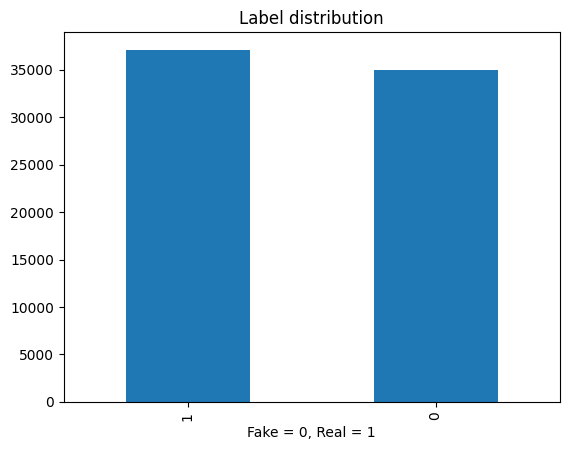

In [63]:
fn_df['label'].value_counts().plot(kind='bar')
plt.title("Label distribution")
plt.xlabel("Fake = 0, Real = 1")

In [64]:
fn_vectorizer = CountVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2), max_df = 0.02, min_df = 0.005)
# fn_df["combined_text"] = fn_df["title"] + fn_df["text"]
# fn_clean = fn_df.dropna(subset=["combined_text"])

# fn_clean.head()
fn_vector = fn_vectorizer.fit_transform(fn_clean["combined_text"])
fn_vocab = list(fn_vectorizer.vocabulary_.keys())

print("Vocab sample: ", fn_vocab[:20])

KeyboardInterrupt: 

In [ ]:
## Compare vocabs pulled from YouTube and FakeNews datasets
print("Length of YouTube vocab: ", len(vect_vocab))
print("Length of Fake News vocab: ", len(fn_vocab))
shared_vocab = list(set(vect_vocab) & set(fn_vocab))
print("Vocab overlap: ", len(shared_vocab))
print(shared_vocab)
print(len(shared_vocab))

Length of YouTube vocab:  2755
Length of Fake News vocab:  5000
Vocab overlap:  380
['nick', 'hair', 'clash', 'escape', 'le', 'ends', 'tour', 'warner', 'fame', 'box', 'representation', 'dream', 'boom', 'gang', 'chain', 'publicity', 'alex', 'journey', 'miss', 'doctor', 'arena', 'tip', 'items', 'plot', 'smith', '56', '57', 'ring', 'new world', '44', 'producers', 'burn', 'associate', 'dance', 'origin', 'stewart', 'keeps', 'voluntary', 'iron', 'master', 'loved', 'tim', 'clip', 'library', 'killer', 'purposes', 'affiliate', 'completed', 'stupid', 'edge', 'okay', 'epic', 'breaks', 'tech', 'dump', 'wild', '42', 'sky', 'cooper', 'witch', 'mode', 'bag', 'reveal', 'channels', 'findings', 'constantly', 'feed', 'invite', 'alternate', 'player', '52', 'experiences', 'returning', 'sam', 'skin', 'spot', 'electric', 'latin america', 'tears', 'let know', '53', 'platforms', '58', 'meets', 'switch', 'lay', 'empire', 'jon', 'fallout', 'machine', 'alien', 'shoot', 'rick', 'rely', 'dave', 'insane', 'podcast',

In [65]:

labeled_yt_df = pd.DataFrame()
labeled_yt_df['text'] = yt_df['title']
labeled_yt_df['label'] = 0


labeled_fn_df = pd.DataFrame()
labeled_fn_df['text'] = fn_df["title"]
labeled_fn_df['label'] = 1


labeled_df = pd.concat([labeled_fn_df, labeled_yt_df], ignore_index=True)
labeled_df = labeled_df.dropna()
del labeled_yt_df
del labeled_fn_df
print(labeled_df)

                                                     text  label
0       LAW ENFORCEMENT ON HIGH ALERT Following Threat...      1
2       UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...      1
3       Bobby Jindal, raised Hindu, uses story of Chri...      1
4       SATAN 2: Russia unvelis an image of its terrif...      1
5       About Time! Christian Group Sues Amazon and SP...      1
...                                                   ...    ...
104729                                  A-Side or B-Side?      0
104730             Get your girl treasure, not chocolate.      0
104731                  He Said “Please” | Tamon's B-Side      0
104732  You and I Are Polar Opposites | Dub Trailer | ...      0
104733  Re:ZERO -Starting Life in Another World- Seaso...      0

[104176 rows x 2 columns]


In [66]:
combined_vect = CountVectorizer(stop_words='english', max_features=2048, ngram_range=(1,2), max_df = 0.015, min_df = 0.003)
combo_vector = combined_vect.fit_transform(labeled_df["text"])

combo_vocab = list(combined_vect.vocabulary_.keys())
print(combo_vocab)

['law', 'high', 'general', 'protesters', 'home', 'north', 'story', '2016', 'world', 'takes', 'time', 'group', 'hate', 'national', 'fake', 'games', 'american', 'like', 'america', 'gop', 'senator', 'right', 'brexit', 'eu', 'calls', 'health', 'family', 'change', 'political', 'woman', 'way', 'major', 'liberal', 'president trump', 'judge', 'email', 'bad', 'gives', 'end', 'days', 'claims', 'saudi', 'support', 'hillary clinton', 'best', 'government', 'pay', 'supreme', 'court', 'won', 'texas', 'voter', 'case', 'supreme court', 'islamic', 'iraq', 'islamic state', 'states', 'public', 'old', 'students', 'sex', 'head', 'german', 'talks', 'china', 'trade', 'korea', 'north korea', 'man', 'comment', 'coming', 'goes', 'media', 'iran', 'turkey', 'syria', 'don', 'breaking', 'putin', 'attack', 'emails', 'great', 'wants', 'deal', 'uk', 'trump says', 'comey', 'tax', 'plan', 'death', 'left', 'social', 'review', 'conservative', 'job', 'republicans', 'climate', 'obamacare', 'healthcare', 'host', 'democratic',

Text(0.5, 0, 'YouTube = 0, News = 1')

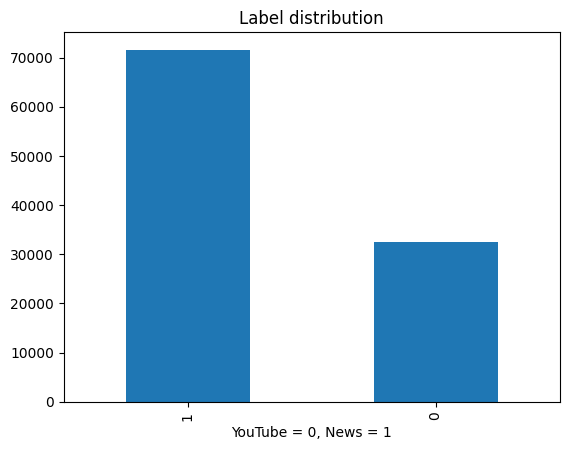

In [67]:
labeled_df['label'].value_counts().plot(kind='bar')
plt.title("Label distribution")
plt.xlabel("YouTube = 0, News = 1")

In [68]:
import gensim.downloader as api
embedding_model = api.load("word2vec-google-news-300")
EMBEDDING_DIM = 300

vectorizer = CountVectorizer(
    stop_words="english",   
    # min_df=2,               
    # max_df=0.95,            
)
vectorizer.fit(labeled_df["text"])
tokenizer = vectorizer.build_analyzer()

def document_to_vector(text, model, dim):
    """
    CREDIT: Claude Sonnet 4.6
    Tokenize a document and average the embeddings of known words.
    Words not in the embedding vocabulary are skipped.
    Returns a zero vector if no words are found.
    """
    tokens = tokenizer(text)
    vectors = []
    for token in tokens:
        if token in model:
            vectors.append(model[token])

    if vectors:
        return np.mean(vectors, axis=0)  # average across all word vectors
    else:
        return np.zeros(dim)             # fallback for empty/unknown documents

doc_vectors = np.array([
    document_to_vector(doc, embedding_model, EMBEDDING_DIM)
    for doc in labeled_df["text"]
])

PC1 explains 5.6% of variance
PC2 explains 4.4% of variance
Total: 10.0%


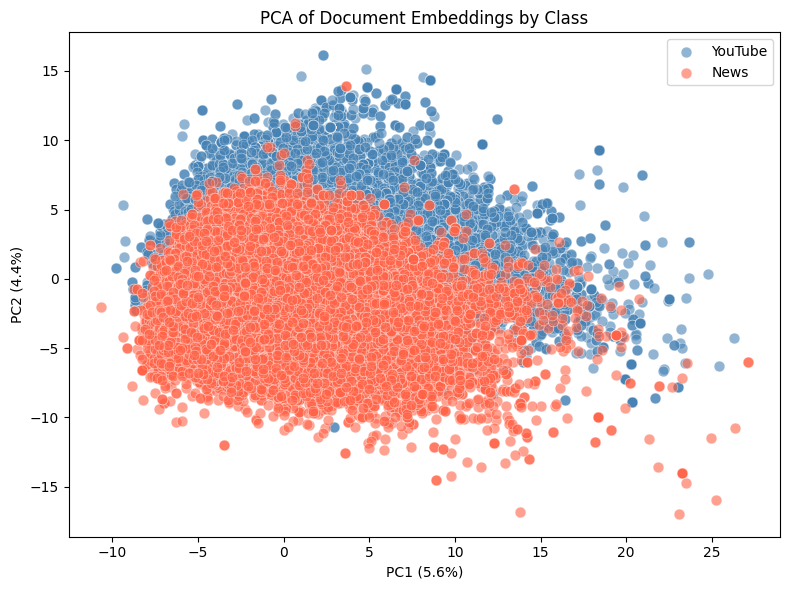

In [69]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
vectors_scaled = scaler.fit_transform(doc_vectors)

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors_scaled)
explained = pca.explained_variance_ratio_
print(f"PC1 explains {explained[0]*100:.1f}% of variance")
print(f"PC2 explains {explained[1]*100:.1f}% of variance")
print(f"Total: {sum(explained)*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["steelblue", "tomato"]
class_names = ["YouTube", "News"]

for class_id in [0, 1]:
    mask = np.array(labeled_df['label']) == class_id
    ax.scatter(vectors_2d[mask, 0], vectors_2d[mask, 1],
               label=class_names[class_id], color=colors[class_id],
               alpha=0.6, edgecolors="white", linewidths=0.4, s=60)

ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
ax.set_title("PCA of Document Embeddings by Class")
ax.legend()
plt.tight_layout()
plt.show()


